Saved statistics table to 'category_statistics.png'


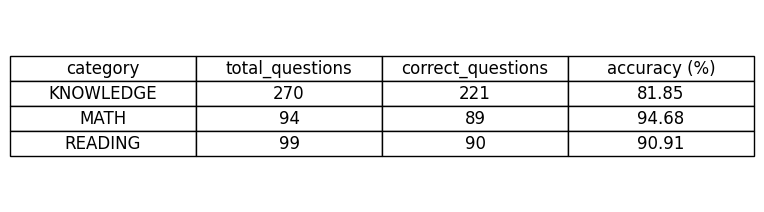

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load your actual CSV data
# Replace 'result.csv' with the actual path to your file
df = pd.read_csv('model_evaluation_results12.csv')

# 2. Ensure 'is_true' is evaluated as a boolean
# This safely converts strings like 'TRUE' or 'True' into boolean True
df['is_true'] = df['is_true'].astype(str).str.strip().str.upper() == 'TRUE'

# 3. Calculate statistics: total questions and correct answers per category
stats = df.groupby('category').agg(
    total_questions=('qid', 'count'),
    correct_questions=('is_true', 'sum')
).reset_index()

# 4. Calculate accuracy percentage
stats['accuracy (%)'] = (stats['correct_questions'] / stats['total_questions'] * 100).round(2)

# 5. Create a visual table to save as an image
# Dynamically adjust the figure height based on the number of categories
fig_height = len(stats) * 0.5 + 1
fig, ax = plt.subplots(figsize=(8, fig_height)) 
ax.axis('tight')
ax.axis('off')

# Render the dataframe as a matplotlib table
table = ax.table(
    cellText=stats.values, 
    colLabels=stats.columns, 
    cellLoc='center', 
    loc='center'
)

# 6. Style the table for readability
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5) # Scales the cells (width, height)

# 7. Save the resulting table as a PNG image
plt.savefig('category_statistics.png', bbox_inches='tight', dpi=300)
print("Saved statistics table to 'category_statistics.png'")

